<a href="https://colab.research.google.com/github/NoeliaFerrero/Comi-96160-Data-Science-II-Machine-Learning-para-la-Ciencia-de-Datos-Diplomaturas/blob/main/Semana%202%20BD%20y%20Aplicaciones/Impacto_del_Precio_de_Combustibles_en_las_B%C3%BAsquedas_Digitales_en_Argentina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color='green'>***PROYECTO INTEGRADOR***</font>

# ⛽ Impacto del Precio de Combustibles en las Búsquedas Digitales en Argentina

## Caso de negocio

Bienvenidos al equipo de Business Intelligence de **DATAFUEL S.A.**

La gerencia comercial observó que, cada vez que aumenta el precio de los combustibles, parece cambiar el comportamiento de búsqueda de los consumidores en Internet.

Nuestro desafío será construir un pequeño pipeline de datos que permita integrar distintas fuentes de información para responder la siguiente pregunta:

> **¿Existe alguna relación entre el precio de los combustibles y el interés de búsqueda de los argentinos?**

Durante esta práctica recorreremos todas las etapas de un proceso ETL (Extract - Transform - Load), utilizando Python, Pandas y SQL.

Al finalizar, generaremos una base de datos lista para ser analizada desde Power BI.


## 📌 Contexto:
En Argentina, las fluctuaciones en el precio de los combustibles representan un evento macroeconómico que altera de inmediato la conducta y prioridades del consumidor. Ante el anuncio o concreción de una suba en el surtidor, los usuarios recurren masivamente a motores de búsqueda para comparar precios, evaluar promociones, buscar alternativas de transporte o gestionar su presupuesto personal.

## 🎯 Objetivo de la Práctica
Como DS, el objetivo es **diseñar y construir una arquitectura de base de datos relacional en memoria** utilizando `SQLite` y `Python` en Google Colab para integrar dos fuentes clave de información:
1. **Precios Oficiales en Surtidor (Resolución 314/2016):** Datos abiertos suministrados por la Secretaría de Energía sobre estaciones de servicio, productos, provincias y precios reales declarados.
https://datos.gob.ar/dataset/energia-precios-surtidor---resolucion-3142016/archivo/energia_f8dda0d5-2a9f-4d34-b79b-4e63de3995df
2. **Registro de Búsquedas Digitales (Simulación de Interés del Consumidor):** Logs de volúmenes de búsqueda categorizados por provincia, términos frecuentes y eventos de aumento.

A través de esta práctica aprenderemos a:
* Cargar y transformar archivos `.csv` heterogéneos mediante `Pandas`.
* Crear una base de datos relacional SQL (`SQLite`) y definir sus tablas.
* Realizar consultas exploratorias (EDA - *Exploratory Data Analysis*) aplicando `JOIN`, agregaciones (`GROUP BY`), filtros (`WHERE`) y subconsultas.
* Responder preguntas de negocio evaluando la correlación entre las variaciones reales de precio y el volumen de búsquedas digitales.

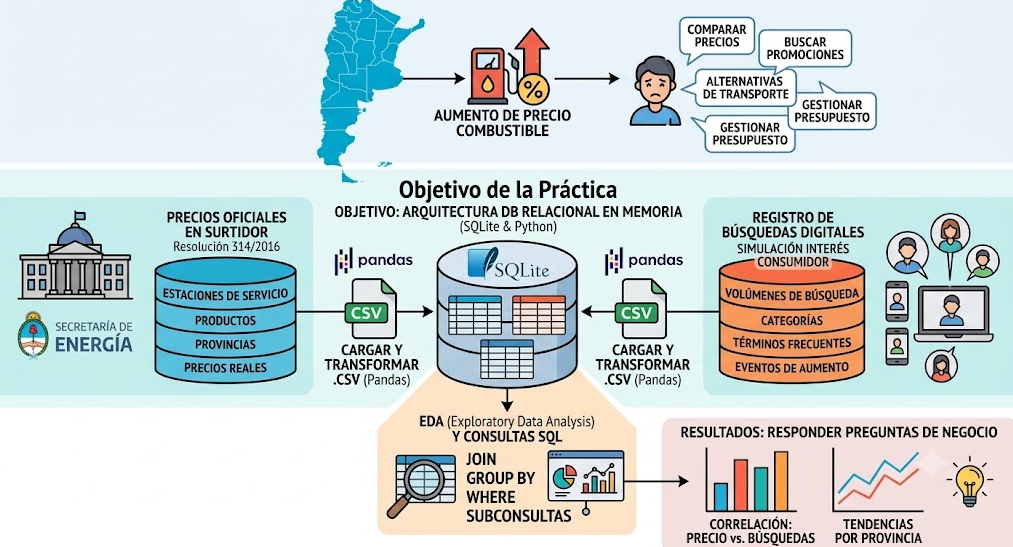

---
# 🧠 Guía Teórica: ¿Por qué usamos SQL en lugar de Pandas (o ambos)?

Es muy común preguntarse: *¿Si Pandas puede hacer filtros y agrupar datos, para qué necesitamos SQL?*

En el entorno profesional, **SQL y Pandas no compiten, sino que se complementan**.

---

### 1. La regla de oro: ¿Cuándo usar cada herramienta?

| Criterio | 🛢️ SQL (Motor de Base de Datos) | 🐼 Pandas (Librería Python) |
| :--- | :--- | :--- |
| **Lugar de ejecución** | Corre en el **servidor/motor de base de datos** (PostgreSQL, BigQuery, SQLite). | Corre en la **memoria RAM** de tu máquina local o entorno (Google Colab). |
| **Volumen de datos** | Pensado para **Gigabytes, Terabytes o Petabytes** (Millones de filas). | Ideal para **Megabytes o un par de Gigabytes** (Lo que quepa en tu RAM). |
| **Objetivo principal** | **Extraer, filtrar, limpiar y agregar** datos (*Fase ETL / Querying*). | **Explorar, realizar análisis estadístico, ML y gráficos** (*EDA*). |
| **Acceso y Seguridad** | Multiusuario con permisos, concurrencia y **fuente centralizada de la verdad**. | Archivo o script ejecutado individualmente. |

---

### 2. Ventajas clave de procesar los datos con SQL

1. **Eficiencia de Memoria RAM (Evitar el colapso del sistema):**
   * Si intentás cargar un dataset de 50 millones de filas directo en Pandas, la memoria de Colab o de tu computadora va a colapsar (*Out of Memory*).
   * **Con SQL:** Podés procesar esos 50 millones de filas dentro del motor de base de datos y hacer que la consulta SQL te devuelva a Python **únicamente un resumen de 20 filas** (por ejemplo, el promedio por provincia).

2. **Simplicidad para `JOINs` y relaciones complejas:**
   * En SQL, vincular múltiples tablas relacionales mediante `INNER JOIN` o `LEFT JOIN` con filtros `WHERE` es nativo, muy legible y rápido.
   * En Pandas, hacer múltiples `.merge()` requiere gestionar índices, memoria y duplicados manualmente.

3. **Estándar Universal de la Industria:**
   * Todas las empresas (bancos, e-commerce, apps, entes públicos) guardan su información en bases de datos relacionales. Saber SQL le permite al analista ir directo a la fuente sin depender de que alguien le exporte un archivo `.csv`.

> 💡 **En resumen:** *Hacé las filtraciones, uniones (`JOIN`) y agrupamientos pesados en **SQL**, y traé a **Pandas** solo los resultados listos para graficar o analizar.*
---

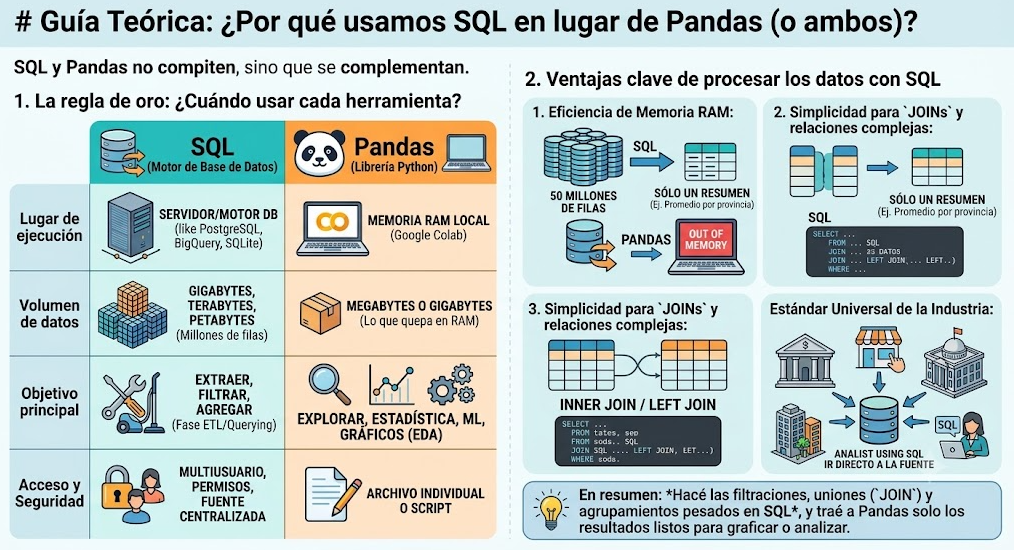

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# -------------------------------------------------------------------------
# 1. CARGA DEL DATASET DE BÚSQUEDAS
# -------------------------------------------------------------------------
df_busquedas = pd.read_csv('busquedas_combustible_argentina_2023_2024.csv')

# Formatear la columna de fecha a YYYY-MM-DD
df_busquedas['fecha'] = pd.to_datetime(df_busquedas['fecha']).dt.strftime('%Y-%m-%d')


> 🔍 **Debate a nivel Arquitectura:** ¿Por qué usamos un CSV local en lugar de consultar la URL directa del Gobierno?
>
> 1. **Estabilidad y Resiliencia:** Evitamos que la clase falle si el servidor del portal de datos públicos se cae o está lento.
> 2. **Reproducibilidad:** Mantenemos una "versión congelada" de los datos para garantizar que todos los alumnos obtengan exactamente los mismos resultados.
> 3. **Performance:** Evitamos descargar megabytes repetidamente a través de la red en cada ejecución del notebook.

In [ ]:
# -------------------------------------------------------------------------
# 2. CARGA DEL DATASET OFICIAL DE PRECIOS EN SURTIDOR
# -------------------------------------------------------------------------
# Opción A (Recomendada para las pruebas): Archivo Local (Rápido y Estable)
path_precios = '/content/precios-en-surtidor-resolucin-3142016 (3).csv'

# Opción B (Entorno de Producción): URL Directa desde datos.gob.ar
# path_precios = 'https://datos.gob.ar/dataset/energia-precios-surtidor---resolucion-3142016/archivo/energia_f8dda0d5-2a9f-4d34-b79b-4e63de3995df'

try:
    df_precios = pd.read_csv(path_precios)
    print("✅ CSV de Precios cargado correctamente.")
except Exception as e:
    print(f"⚠️ Error al cargar el archivo: {e}")

# Limpieza ligera de nombres de columnas por si hay espacios invisibles
df_precios.columns = df_precios.columns.str.strip().str.lower()

# Mapeo exacto basado en las columnas reales del archivo:
# ['indice_tiempo', 'idempresa', 'cuit', 'empresa', 'direccion', 'localidad',
#  'provincia', 'region', 'idproducto', 'producto', 'idtipohorario', 'tipohorario',
#  'precio', 'fecha_vigencia', 'idempresabandera', 'empresabandera', 'latitud', 'longitud', 'geojson']

cols_interes = {
    'empresabandera': 'empresa_bandera',
    'empresa': 'razon_social',
    'provincia': 'provincia',
    'localidad': 'localidad',
    'producto': 'producto',
    'precio': 'precio',
    'fecha_vigencia': 'fecha_vigencia',
    'latitud': 'latitud',
    'longitud': 'longitud'
}

# Seleccionamos y renombramos sólo las columnas útiles
df_precios_clean = df_precios[list(cols_interes.keys())].rename(columns=cols_interes)

# Normalizar la fecha de vigencia cortando la hora (si la hubiera) para dejar YYYY-MM-DD
df_precios_clean['fecha_vigencia'] = pd.to_datetime(df_precios_clean['fecha_vigencia'], errors='coerce').dt.strftime('%Y-%m-%d')

✅ CSV de Precios cargado correctamente.


In [ ]:
# -------------------------------------------------------------------------
# 3. CREACIÓN DE LA BASE DE DATOS SQLITE Y CARGA DE LAS TABLAS
# -------------------------------------------------------------------------
conn = sqlite3.connect('estaciones_y_busquedas.db')

# Guardar ambas tablas en SQLite
df_precios_clean.to_sql('precios_surtidor', conn, if_exists='replace', index=False)
df_busquedas.to_sql('busquedas_digitales', conn, if_exists='replace', index=False)

print("✅ Base de datos cargada sin errores:")
print(f"  - Tabla 'precios_surtidor': {len(df_precios_clean)} filas.")
print(f"  - Tabla 'busquedas_digitales': {len(df_busquedas)} filas.")

✅ Base de datos cargada sin errores:
  - Tabla 'precios_surtidor': 36759 filas.
  - Tabla 'busquedas_digitales': 2840 filas.


## 🔍 Paso 1: Exploración Inicial y Entendimiento de las Tablas (EDA)
Antes de cruzar la información, realizaremos consultas generales para comprender la estructura de ambas tablas, los rangos de precios por tipo de producto y la distribución geográfica.

In [ ]:
# Función auxiliar para ejecutar SQL y presentar los resultados tabulados
def query_sql(sql_code):
    return pd.read_sql_query(sql_code, conn)

# 1. Inspeccionar las primeras filas de la tabla de precios
print("--- Muestra de Precios Oficiales en Surtidor ---")
display(query_sql("SELECT * FROM precios_surtidor LIMIT 5;"))

# 2. Resumen de precios promedio y extremos por tipo de producto
query_resumen_precios = """
SELECT
    producto,
    COUNT(*) AS cantidad_estaciones_reportando,
    ROUND(AVG(precio), 2) AS precio_promedio,
    ROUND(MIN(precio), 2) AS precio_minimo,
    ROUND(MAX(precio), 2) AS precio_maximo
FROM precios_surtidor
GROUP BY producto
ORDER BY precio_promedio DESC;
"""
print("--- Resumen por Tipo de Producto ---")
display(query_sql(query_resumen_precios))

--- Muestra de Precios Oficiales en Surtidor ---


,empresa_bandera,razon_social,provincia,localidad,producto,precio,fecha_vigencia,latitud,longitud
0,PUMA,10 DE SETIEMBRE S.A.,BUENOS AIRES,LOMAS DEL MIRADOR,Gas Oil Grado 2,2190.0,2026-05-01,-34.658476,-58.529443
1,PUMA,10 DE SETIEMBRE S.A.,BUENOS AIRES,LOMAS DEL MIRADOR,Gas Oil Grado 2,2190.0,2026-05-01,-34.658476,-58.529443
2,PUMA,10 DE SETIEMBRE S.A.,BUENOS AIRES,LOMAS DEL MIRADOR,Gas Oil Grado 3,2478.0,2026-05-01,-34.658476,-58.529443
3,PUMA,10 DE SETIEMBRE S.A.,BUENOS AIRES,LOMAS DEL MIRADOR,Gas Oil Grado 3,2479.0,2026-05-01,-34.658476,-58.529443
4,PUMA,10 DE SETIEMBRE S.A.,BUENOS AIRES,LOMAS DEL MIRADOR,GNC,599.9,2026-04-02,-34.658476,-58.529443


--- Resumen por Tipo de Producto ---


,producto,cantidad_estaciones_reportando,precio_promedio,precio_minimo,precio_maximo
0,Gas Oil Grado 3,8194,1678.58,16.95,3000.0
1,Nafta (premium) de más de 95 Ron,8125,1644.66,20.70,3000.0
2,Gas Oil Grado 2,8372,1473.80,13.71,2935.0
3,Nafta (súper) entre 92 y 95 Ron,8348,1428.53,17.52,2800.0
4,GNC,3720,622.97,7.00,1390.0


## 🔗 Paso 2: Análisis Cruzado mediante JOIN (Interés Digital vs. Precios Reales)
A continuación, vincularemos el volumen de búsquedas con los reportes oficiales de aumento de precio. La relación se establece cruzando la **provincia** y las **fechas clave** donde se registraron incrementos.

In [ ]:
query_impacto_aumentos = """
SELECT
    b.fecha,
    b.provincia,
    b.categoria,
    b.termino_busqueda,
    p.producto,
    b.volumen_busquedas,
    ROUND(AVG(p.precio), 2) AS precio_promedio_nafta_super
FROM busquedas_digitales b
LEFT JOIN precios_surtidor p
    ON b.fecha = p.fecha_vigencia
WHERE b.evento_aumento = 1
  AND (p.producto LIKE '%GNC%' OR p.producto IS NULL)
GROUP BY b.fecha, b.provincia, b.termino_busqueda, p.producto
ORDER BY b.volumen_busquedas DESC
LIMIT 10;
"""
print("--- Top 10 Búsquedas en Días de Aumento con Precio Promedio Surtidor ---")
display(query_sql(query_impacto_aumentos))

--- Top 10 Búsquedas en Días de Aumento con Precio Promedio Surtidor ---


,fecha,provincia,categoria,termino_busqueda,producto,volumen_busquedas,precio_promedio_nafta_super
0,2024-03-01,Buenos Aires,Precios,precio nafta hoy argentina,GNC,22246,538.00
1,2023-11-01,Buenos Aires,Descuentos,descuento nafta galicia,None,21003,NaN
2,2024-02-01,Buenos Aires,Precios,cuanto sube la nafta,GNC,20279,397.00
3,2023-12-13,CABA,Descuentos,bbva descuento ypf,GNC,19986,249.90
4,2023-06-17,Buenos Aires,Precios,cuanto cuesta llenar el tanque,None,19866,NaN
5,2023-04-16,CABA,Descuentos,aplicacion ypf descuentos,None,19825,NaN
6,2023-02-16,Buenos Aires,Precios,cuanto cuesta llenar el tanque,GNC,19475,99.90
7,2023-11-25,CABA,Alternativas,horarios colectivo urbano,None,18815,NaN
8,2023-08-18,Buenos Aires,Descuentos,promociones cuenta dni nafta,GNC,18810,181.96
9,2023-11-01,Buenos Aires,Precios,precio gasoil axion,None,18803,NaN


In [ ]:
# Consulta 3: Identificar las búsquedas de mayor impacto vinculadas a aumentos y comparar con el precio de Nafta Súper de YPF
query_impacto_aumentos = """
SELECT
    b.fecha,
    b.provincia,
    b.categoria,
    b.termino_busqueda,
    p.producto,
    b.volumen_busquedas,
    ROUND(AVG(p.precio), 2) AS precio_promedio_nafta_super
FROM busquedas_digitales b
LEFT JOIN precios_surtidor p
    ON b.provincia = p.provincia
    AND b.fecha = p.fecha_vigencia
WHERE b.evento_aumento = 1
  AND (p.producto LIKE '%Gas%' OR p.producto IS NULL)
GROUP BY b.fecha, b.provincia, b.termino_busqueda, p.producto
ORDER BY b.volumen_busquedas DESC
LIMIT 10;
"""

print("--- Top 10 Búsquedas en Días de Aumento con Precio Promedio Surtidor ---")
display(query_sql(query_impacto_aumentos))

--- Top 10 Búsquedas en Días de Aumento con Precio Promedio Surtidor ---


,fecha,provincia,categoria,termino_busqueda,producto,volumen_busquedas,precio_promedio_nafta_super
0,2024-03-01,Buenos Aires,Precios,precio nafta hoy argentina,None,22246,None
1,2023-11-01,Buenos Aires,Descuentos,descuento nafta galicia,None,21003,None
2,2024-06-01,Buenos Aires,Precios,cuanto cuesta llenar el tanque,None,20728,None
3,2024-02-01,Buenos Aires,Precios,cuanto sube la nafta,None,20279,None
4,2023-12-13,CABA,Descuentos,bbva descuento ypf,None,19986,None
5,2023-06-17,Buenos Aires,Precios,cuanto cuesta llenar el tanque,None,19866,None
6,2023-04-16,CABA,Descuentos,aplicacion ypf descuentos,None,19825,None
7,2023-02-16,Buenos Aires,Precios,cuanto cuesta llenar el tanque,None,19475,None
8,2024-05-01,CABA,Estaciones,axion energia ubicaciones,None,19130,None
9,2023-11-25,CABA,Alternativas,horarios colectivo urbano,None,18815,None


In [ ]:
def query_sql(sql_code):
    return pd.read_sql_query(sql_code, conn)

# Consulta 4. Resumen de provincias por fuente de Datos
query_resumen_precios = """
SELECT
    provincia,
    COUNT(*) AS cantidad_por_provincia
FROM precios_surtidor
GROUP BY provincia;
"""
print("--- Resumen por Provincia ---")
display(query_sql(query_resumen_precios))

--- Resumen por Provincia ---


,provincia,cantidad_por_provincia
0,BUENOS AIRES,13822
1,CAPITAL FEDERAL,1630
2,CATAMARCA,286
3,CHACO,630
4,CHUBUT,566
5,CORDOBA,4472
6,CORRIENTES,726
7,ENTRE RIOS,1670
8,FORMOSA,278
9,JUJUY,412


In [ ]:
def query_sql(sql_code):
    return pd.read_sql_query(sql_code, conn)

# Consulta 4. Resumen de provincias por fuente de Datos
query_resumen_precios = """
SELECT
    provincia,
    COUNT(*) AS cantidad_por_provincia
FROM busquedas_digitales
GROUP BY provincia;
"""
print("--- Resumen por Provincia ---")
display(query_sql(query_resumen_precios))

--- Resumen por Provincia ---


,provincia,cantidad_por_provincia
0,Buenos Aires,851
1,CABA,578
2,Córdoba,323
3,Entre Ríos,92
4,Mendoza,249
5,Misiones,79
6,Neuquén,108
7,Salta,122
8,Santa Fe,293
9,Tucumán,145


Falta pasar la columna provincias a mayusculas!!

## 📊 Paso 3: Resolución de Preguntas de Negocio mediante Consultas Avanzadas
Proponemos las siguientes consignas de análisis de negocio para resolver con SQL:
1. **Preferencias por Provincia:** ¿Qué categoría de búsqueda (*Descuentos*, *Precios*, *Alternativas*) predomina en cada provincia durante los eventos de aumento?
2. **Análisis de Dispersión por Bandera:** ¿Cuál es la bandera/empresa con el precio promedio más alto reportado en el país?

In [ ]:
# Pregunta 1: Categorías preferidas por Provincia en Días de Aumento
query_categorias_provincia = """
SELECT
    provincia,
    categoria,
    SUM(volumen_busquedas) AS total_volumen_busquedas
FROM busquedas_digitales
WHERE evento_aumento = 1
GROUP BY provincia, categoria
ORDER BY provincia, total_volumen_busquedas DESC;
"""

print("--- Volumen Total por Categoría y Provincia en Días de Aumento ---")
display(query_sql(query_categorias_provincia))

--- Volumen Total por Categoría y Provincia en Días de Aumento ---


,provincia,categoria,total_volumen_busquedas
0,Buenos Aires,Precios,1552977
1,Buenos Aires,Descuentos,1293019
2,Buenos Aires,Estaciones,532664
3,Buenos Aires,Alternativas,360346
4,CABA,Precios,956767
5,CABA,Descuentos,852750
6,CABA,Estaciones,215828
7,CABA,Alternativas,155476
8,Córdoba,Descuentos,386605
9,Córdoba,Precios,361197


In [ ]:
# Pregunta 2: Análisis de Dispersión por Bandera / Empresa
query_dispersion_bandera = """
SELECT
    empresa_bandera,
    COUNT(*) AS cantidad_surtidores,
    ROUND(AVG(precio), 2) AS precio_promedio,
    ROUND(MIN(precio), 2) AS precio_minimo,
    ROUND(MAX(precio), 2) AS precio_maximo,
    ROUND(MAX(precio) - MIN(precio), 2) AS dispersion_precio
FROM precios_surtidor
WHERE empresa_bandera IS NOT NULL AND empresa_bandera != ''
GROUP BY empresa_bandera
ORDER BY precio_promedio DESC;
"""

print("--- PRECIO PROMEDIO Y DISPERSIÓN POR BANDERA EN ARGENTINA ---")
df_banderas = query_sql(query_dispersion_bandera)
display(df_banderas)

# Extraer automáticamente la respuesta
empresa_lider = df_banderas.iloc[0]['empresa_bandera']
precio_max_prom = df_banderas.iloc[0]['precio_promedio']

print(f"\n💡 CONCLUSIÓN: La empresa/bandera con el precio promedio más alto reportado es '{empresa_lider}' con un promedio de ${precio_max_prom}.")

--- PRECIO PROMEDIO Y DISPERSIÓN POR BANDERA EN ARGENTINA ---


,empresa_bandera,cantidad_surtidores,precio_promedio,precio_minimo,precio_maximo,dispersion_precio
0,SHELL C.A.P.S.A.,7841,1759.84,16.22,2699.00,2682.78
1,AXION,4775,1703.70,8.00,2890.00,2882.00
2,GULF,826,1648.09,21.99,2590.09,2568.10
3,VOY,280,1607.44,88.40,2635.00,2546.60
4,PUMA,3538,1603.42,7.00,2619.00,2612.00
5,DAPSA S.A.,1030,1425.33,11.95,2564.00,2552.05
6,OIL COMBUSTIBLES S.A.,10,1334.78,619.90,1622.00,1002.10
7,YPF,13206,1296.11,7.78,2614.00,2606.22
8,REFINOR,538,1105.38,18.13,2589.00,2570.87
9,BLANCA,4711,1079.95,7.00,3000.00,2993.00



💡 CONCLUSIÓN: La empresa/bandera con el precio promedio más alto reportado es 'SHELL C.A.P.S.A.' con un promedio de $1759.84.


In [ ]:
# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

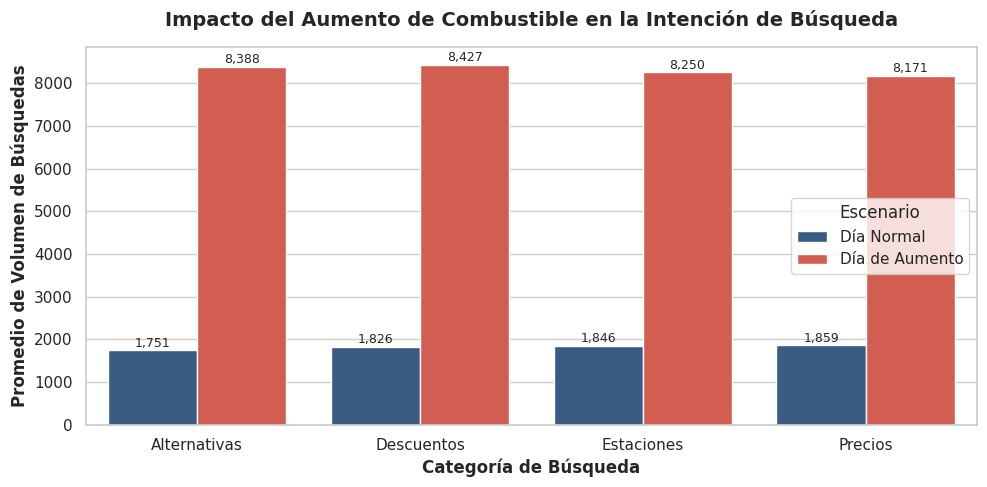

In [ ]:
# -------------------------------------------------------------------------
# GRÁFICO 1: Volumen Promedio de Búsquedas según Evento de Aumento (Consulta SQL + Chart)
# -------------------------------------------------------------------------
query_grafico_1 = """
SELECT
    CASE WHEN evento_aumento = 1 THEN 'Día de Aumento' ELSE 'Día Normal' END AS tipo_dia,
    categoria,
    AVG(volumen_busquedas) AS promedio_busquedas
FROM busquedas_digitales
GROUP BY tipo_dia, categoria;
"""

df_g1 = query_sql(query_grafico_1)

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(
    data=df_g1,
    x='categoria',
    y='promedio_busquedas',
    hue='tipo_dia',
    palette=['#2b5c8f', '#e74c3c']
)

plt.title('Impacto del Aumento de Combustible en la Intención de Búsqueda', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoría de Búsqueda', fontweight='bold')
plt.ylabel('Promedio de Volumen de Búsquedas', fontweight='bold')
plt.legend(title='Escenario')

# Agregar valores arriba de cada barra
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")



/tmp/ipykernel_1571/1300757644.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


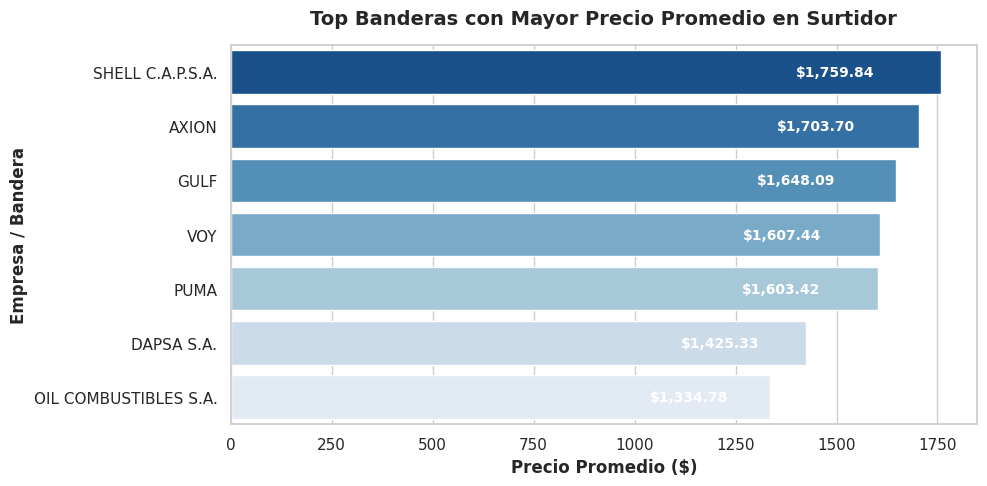

In [ ]:
# -------------------------------------------------------------------------
# GRÁFICO 2: Top 7 Banderas con Mayor Precio Promedio (Consulta SQL + Chart)
# -------------------------------------------------------------------------
query_grafico_2 = """
SELECT
    empresa_bandera,
    ROUND(AVG(precio), 2) AS precio_promedio
FROM precios_surtidor
WHERE empresa_bandera IS NOT NULL AND empresa_bandera != ''
GROUP BY empresa_bandera
ORDER BY precio_promedio DESC
LIMIT 7;
"""

df_g2 = query_sql(query_grafico_2)

plt.figure(figsize=(10, 5))
ax2 = sns.barplot(
    data=df_g2,
    x='precio_promedio',
    y='empresa_bandera',
    palette='Blues_r'
)

plt.title('Top Banderas con Mayor Precio Promedio en Surtidor', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio Promedio ($)', fontweight='bold')
plt.ylabel('Empresa / Bandera', fontweight='bold')

# Agregar los valores dentro/al lado de las barras
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(f'${width:,.2f}',
                 (width - (width*0.15), p.get_y() + p.get_height() / 2.),
                 ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

---
# 🚀 Resumen del Pipeline de Análisis de Datos (Data Pipeline Summary)

En esta práctica integramos y procesamos información de distintas fuentes aplicando el flujo de trabajo profesional (*Data Pipeline*) que se utiliza en la industria:

---

### 📌 Etapas del Pipeline Ejecutado:

1. **Ingesta y Limpieza de Datos (*Data Ingestion & Cleaning*):**
   * Cargamos los archivos en formato `.csv` utilizando **Pandas**.
   * Normalizamos los tipos de datos (como la estandarización de fechas a `YYYY-MM-DD` y la limpieza de texto en las columnas).

2. **Modelado y Carga en Base de Datos (*Data Modeling & Loading*):**
   * Creamos una base de datos relacional en memoria con **SQLite** (`estaciones_y_busquedas.db`).
   * Poblamos las tablas `precios_surtidor` y `busquedas_digitales` para garantizar una "única fuente de la verdad".

3. **Procesamiento de Negocio con SQL (*SQL Querying & Analysis*):**
   * Realizamos consultas de exploración (**EDA**) para conocer distribuciones y valores de dispersión de precios por bandera.
   * Ejecutamos `JOINs` condicionales para vincular el registro oficial de precios con el comportamiento de búsqueda de los consumidores.
   * Aprovechamos el motor SQL para hacer el trabajo pesado de filtrado y agregación (`GROUP BY`, `AVG`, `SUM`), reduciendo el consumo de memoria RAM.

4. **Visualización e Interpretación de Resultados (*Data Visualization*):**
   * Exportamos únicamente los DataFrames procesados por SQL hacia **Seaborn** y **Matplotlib**.
   * Generamos gráficos de barras para comunicar hallazgos clave de forma clara (diferencia de búsquedas en días de aumento vs. días normales y ranking de banderas con mayor precio).

> 💡 **Lección Clave del Proyecto:** La combinación de **SQL + Python** es el estándar de la industria. SQL gestiona el almacenamiento masivo y las transformaciones pesadas en el servidor, mientras que Python/Pandas se encarga de la exploración fina, las estadísticas y la presentación visual.
---

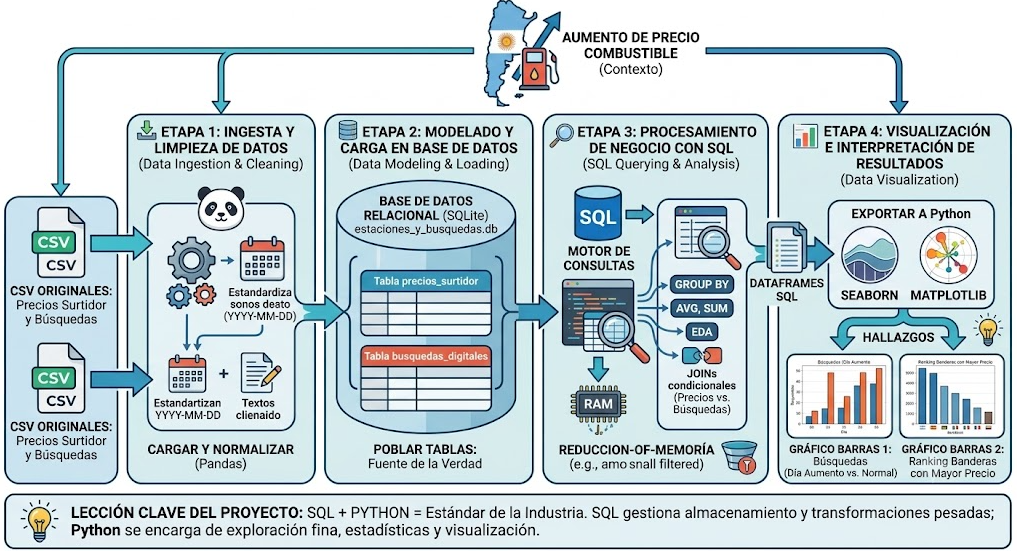

---
## 🔌 Exportación e Integración con Herramientas de BI (Power BI / Tableau)

Una de las grandes ventajas de concentrar los datos en una base de datos relacional como **SQLite** es que todo el modelo relacional queda encapsulado en un único archivo con extensión `.db`.

### ¿Cómo consumir esta base de datos en Power BI?
1. **Descargar el archivo `.db`:** Ejecutá la celda de descarga para guardar `estaciones_y_busquedas.db` en tu computadora.
2. **Conectar desde Power BI Desktop:**
   * Abrí Power BI y seleccioná **Obtener Datos -> Base de Datos SQLite** (o conector **ODBC**).
   * Seleccioná el archivo `.db` descargado.
3. **Cargar el Modelo:** Power BI reconocerá automáticamente las tablas `precios_surtidor` y `busquedas_digitales` para que puedas armar tus relaciones, medidas en **DAX** y dashboards interactivos.
---

In [ ]:
import sqlite3

# Conectar y escribir en el archivo físico .db
conn = sqlite3.connect('estaciones_y_busquedas.db')

# Asegurar que los cambios se guarden (commit) y cerrar la conexión
conn.commit()
conn.close()

print("✅ Archivo 'estaciones_y_busquedas.db' guardado y cerrado correctamente.")

✅ Archivo 'estaciones_y_busquedas.db' guardado y cerrado correctamente.


In [ ]:
from google.colab import files

# Iniciar la descarga del archivo .db a la computadora local
files.download('estaciones_y_busquedas.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import sqlite3
from google.colab import files

# 1. Abrir la conexión a la base de datos
conn = sqlite3.connect('estaciones_y_busquedas.db')

# 2. Leer las tablas desde la BD hacia DataFrames
df_precios_export = pd.read_sql("SELECT * FROM precios_surtidor", conn)
df_busquedas_export = pd.read_sql("SELECT * FROM busquedas_digitales", conn)

# 3. Cerrar la conexión
conn.close()

# 4. Escribir ambas tablas en un archivo Excel con 2 solapas (sheets)
nombre_excel = 'estaciones_y_busquedas_modelo.xlsx'

with pd.ExcelWriter(nombre_excel, engine='openpyxl') as writer:
    df_precios_export.to_excel(writer, sheet_name='Precios_Surtidor', index=False)
    df_busquedas_export.to_excel(writer, sheet_name='Busquedas_Digitales', index=False)

print(f"✅ Archivo Excel '{nombre_excel}' creado con éxito.")

# 5. Iniciar la descarga automática en la computadora
files.download(nombre_excel)

✅ Archivo Excel 'estaciones_y_busquedas_modelo.xlsx' creado con éxito.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title AUTOCALIFICACION
import sys

from termcolor import colored, cprint

print_red_on_cyan = lambda x: cprint(x, "magenta", "on_cyan")

print('**********************************************************************************************')
print('Introduce una puntuacion para AUTOCALIFICAR tu conocimiento sobre los temas vistos\n')
print('Donde 1 es --> "POCO ❌" y 5 es --> "MUCHO ✅" \n')


def lee_entero():
   while True:
       entrada = input("En una escala del 1 al 5 ¿cuanto aprendiste sobre los temas vistos?: ")
       print('**********************************************************************************************')
       try:
           entrada = int(entrada)
           start = '⭐'
           if (entrada < 6 ):
              start = entrada * start
              print(start)
              if (entrada == 1):
                  cprint('De 10, enganchaste una...🤪')
                  cprint('pero no te preocupes, vamos a seguir repasando juntos los temas vistos en clase y tambien')
                  cprint('podemos armar unos ejercicios adicionales, que seguramente van a ser de GRAN ayuda 💪\n')
                  cprint('\t\t👉Recorda que el verdadero camino al éxito, no se trata de no fallar, \n \t\tse trata de ver ese fallo como parte integral del proceso...',"red",attrs=["bold"])
              elif (entrada == 2):
                  cprint('De 10, enganchaste algunas...lo cual es todo un logro😜')
                  cprint('\t\t👉 Recorda que todo aprendizaje depende de tu estado; busca estados \n \t\tfavorables como curiosidad, entusiasmo, satisfacción, etc. ',"magenta",attrs=["bold"])
              elif (entrada == 3):
                  cprint('¡Estamos ATR! con (r) de remo 🛶 whatttt¿??!')
                  cprint('\t\t👉Disfruta el camino, sabiendo que tus logros siempre requerirán \n \t\tde aciertos y errores',"cyan",attrs=["bold"])
              elif (entrada == 4):
                  cprint('Estamos ATR con (r) de ritmo🎼',"green",attrs=["bold"])
                  cprint('\t\t👉Felicitaciones! Vas muy bien, en definitiva el verdadero conocimiento se origina cuando seguimos \n \t\tbuscando nuevos caminos, combinamos conocimientos, iteramos...',"green",attrs=["bold"])
              elif (entrada == 5):
                  cprint('\t\t👉De 10 + IVA🍾',"green",attrs=["bold"])
                  cprint('\t\t👉Felicitaciones por todo lo aprendido hasta ahora, seguí así..!',"green",attrs=["bold"])
              return print (" \n Gracias por participar, esperamos que te lleves algo útil de este notebook 😀 ")
           else:
             cprint ("El numero ingresado no es valido: Por favor, ingresa un valor del 1 al 5","red",attrs=["bold"])
       except ValueError:
           cprint ("La entrada es incorrecta: Por favor, ingresa un caracter del 1 al 5","red",attrs=["bold"])

lee_entero()

**********************************************************************************************
Introduce una puntuacion para AUTOCALIFICAR tu conocimiento sobre los temas vistos

Donde 1 es --> "POCO ❌" y 5 es --> "MUCHO ✅" 

En una escala del 1 al 5 ¿cuanto aprendiste sobre los temas vistos?: 5
**********************************************************************************************
⭐⭐⭐⭐⭐
		👉De 10 + IVA🍾
		👉Felicitaciones por todo lo aprendido hasta ahora, seguí así..!
 
 Gracias por participar, esperamos que te lleves algo útil de este notebook 😀 


![hamsters](https://media.giphy.com/media/d1E2IByItLUuONMc/giphy.gif)